# Prashun Kafle

# Deliverable 3  Modeling and Evaluation

## 1. Problem Statement

### The goal of this project is to build a predictive model that estimates the number of U.S. land border crossings (Value) at various ports of entry. Using features such as port location (Latitude, Longitude), border type (Border), crossing category (Measure), and date-derived information (Year, Month), we aim to identify patterns and produce reliable crossing-volume predictions. Accurate predictions can assist in resource planning, staffing, and policy decisions at border checkpoints.

## 2. Imports and Setup

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')


## 3. Load and Prepare Cleaned Data

### We reload the original dataset and apply the same cleaning pipeline from Deliverable 2 to ensure the data is ready for modeling.

In [ ]:
# Load raw dataset
df = pd.read_csv('Border_Crossing_Entry_Data.csv')

# Drop the Point column (duplicates lat/lon)
df.drop(columns=['Point'], errors='ignore', inplace=True)

# Fill missing State values
df['State'].fillna('Unknown', inplace=True)

# Filling in missing Latitude / Longitude with median
df['Latitude'].fillna(df['Latitude'].median(), inplace=True)
df['Longitude'].fillna(df['Longitude'].median(), inplace=True)

# Convert Date to Year and Month
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y') #CHAT helped with this to make it more efficient
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Remove duplicates
df.drop_duplicates(inplace=True)

# Strip whitespace from text columns
for col in ['Port Name', 'Measure', 'Border', 'State']:
    df[col] = df[col].str.strip()

print('Dataset shape after cleaning:', df.shape)
df.head()

Dataset shape after cleaning: (406710, 11)


,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Year,Month
0,Jackman,Maine,104,US-Canada Border,2024-01-01,Trucks,6556,45.806,-70.397,2024,1
1,Porthill,Idaho,3308,US-Canada Border,2024-04-01,Trucks,98,49.000,-116.499,2024,4
2,San Luis,Arizona,2608,US-Mexico Border,2024-04-01,Buses,10,32.485,-114.782,2024,4
3,Willow Creek,Montana,3325,US-Canada Border,2024-01-01,Pedestrians,2,49.000,-109.731,2024,1
4,Warroad,Minnesota,3423,US-Canada Border,2024-01-01,Personal Vehicle Passengers,9266,48.999,-95.377,2024,1


## 4. Feature Engineering

### We encode categorical variables using Label Encoding so that all features are numeric before feeding them into our models.

In [ ]:
#categorical columns

#Asked CHATGPT to give me suggestions and it suggested to use Label Encoding for the categorical columns. I have implemented that in the code below.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['Port Name', 'State', 'Border', 'Measure']

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])

# Sort by series so lag features use only past rows
df = df.sort_values(['Port Name', 'Measure', 'Date']).copy()

# Group by route/type combination
grp = df.groupby(['Port Name', 'Measure'])

# Time-series features
df['lag_1'] = grp['Value'].shift(1)
df['lag_3'] = grp['Value'].shift(3)

df['rolling_mean_3'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)

df['rolling_mean_6'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=6, min_periods=1).mean()
)

df['rolling_std_3'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).std()
)

df['diff_1'] = df['lag_1'] - df['lag_3']
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Fill rolling std NaN values created for very early rows
df['rolling_std_3'] = df['rolling_std_3'].fillna(0)

# Drop rows where lag values do not exist yet
df = df.dropna(subset=['lag_1', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'diff_1']).copy()

# Define feature set and target
features = [
    'Port Name_enc', 'State_enc', 'Port Code',
    'Border_enc', 'Measure_enc',
    'Latitude', 'Longitude',
    'Year', 'Month',
    'month_sin', 'month_cos',
    'lag_1', 'lag_3',
    'rolling_mean_3', 'rolling_mean_6',
    'rolling_std_3', 'diff_1'
]

target = 'Value'

X = df[features]
y = df[target]

print("Dataset shape after time-series feature engineering:", df.shape)
df[features + [target]].head()

Dataset shape after time-series feature engineering: (402604, 23)


,Port Name_enc,State_enc,Port Code,Border_enc,Measure_enc,Latitude,Longitude,Year,Month,month_sin,month_cos,lag_1,lag_3,rolling_mean_3,rolling_mean_6,rolling_std_3,diff_1,Value
384325,2,0,3104,0,0,62.615,-141.001,1996,4,8.660254e-01,-0.500000,11.0,9.0,6.666667,6.666667,5.859465,2.0,17
365347,2,0,3104,0,0,62.615,-141.001,1996,5,5.000000e-01,-0.866025,17.0,0.0,9.333333,9.250000,8.621678,17.0,638
389532,2,0,3104,0,0,62.615,-141.001,1996,6,1.224647e-16,-1.000000,638.0,11.0,222.000000,135.000000,360.279059,627.0,5500
379092,2,0,3104,0,0,62.615,-141.001,1996,7,-5.000000e-01,-0.866025,5500.0,17.0,2051.666667,1029.166667,3002.442728,5483.0,6392
384618,2,0,3104,0,0,62.615,-141.001,1996,8,-8.660254e-01,-0.500000,6392.0,638.0,4176.666667,2093.000000,3096.859269,5754.0,6112


In [30]:
# Time-based split: train on earlier data, test on later data
split_date = pd.Timestamp('2023-01-01')

train_df = df[df['Date'] < split_date].copy()
test_df  = df[df['Date'] >= split_date].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("Train date range:", train_df['Date'].min(), "to", train_df['Date'].max())
print("Test date range :", test_df['Date'].min(), "to", test_df['Date'].max())

Training samples: 375626
Test samples: 26978
Train date range: 1996-04-01 00:00:00 to 2022-12-01 00:00:00
Test date range : 2023-01-01 00:00:00 to 2025-12-01 00:00:00


## 5. Modeling Approaches

### We evaluate three regression models of increasing complexity to predict the number of border crossings *Value*. For each model we report:
- **RMSE** (Root Mean Squared Error) — penalizes large errors
- **MAE** (Mean Absolute Error) — average magnitude of errors
- **R²** (Coefficient of Determination) — proportion of variance explained

### 5.1 Model 1 — Linear Regression (Baseline)

#### Linear Regression serves as our baseline. It assumes a linear relationship between the features and the target variable. While it is the simplest model, it gives us a reference point to measure the improvement of more complex models.

In [31]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('Linear Regression')
print(f' RMSE : {rmse_lr:,.2f}')
print(f' MAE : {mae_lr:,.2f}')
print(f' R²  : {r2_lr:.4f}')

Linear Regression
 RMSE : 16,092.14
 MAE : 4,077.66
 R²  : 0.9874


### 5.2 Model 2 — Random Forest Regressor

#### Random Forest is an ensemble of decision trees that captures non-linear relationships and feature interactions. It is more powerful than Linear Regression and provides feature importance rankings, giving interpretability alongside improved accuracy.

Random Forest Regressor
 RMSE : 14,031.79
 MAE  : 2,864.91
 R²   : 0.9904


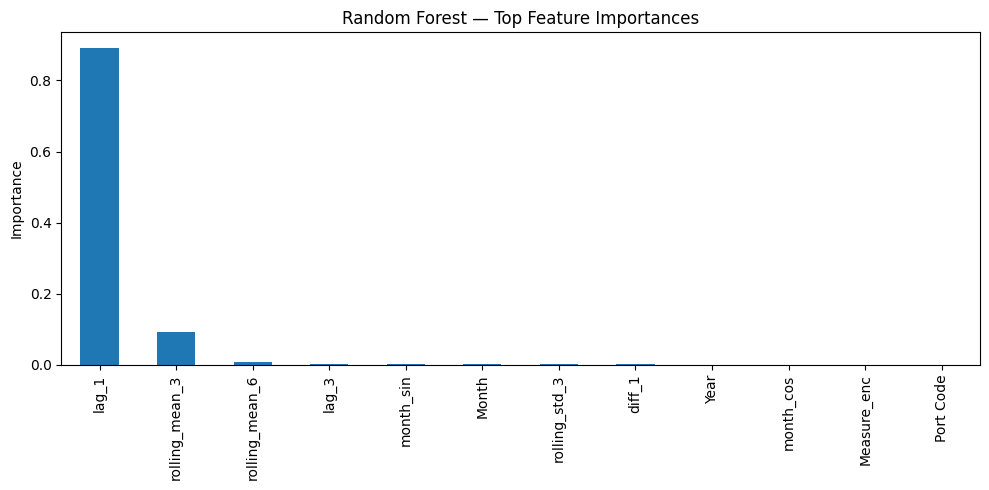

In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Regressor')
print(f' RMSE : {rmse_rf:,.2f}')
print(f' MAE  : {mae_rf:,.2f}')
print(f' R²   : {r2_rf:.4f}')

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(12).plot(kind='bar')
plt.title('Random Forest — Top Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### 5.3 Model 3 — Histogram Gradient Boosting Regressor

#### Histogram Gradient Boosting is a powerful sequential ensemble method that builds trees one at a time, with each tree correcting the errors of the previous ones. It is especially effective on large, complex datasets and natively handles missing values. We expect this to be our best-performing model.

In [33]:
hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
mae_hgb  = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb   = r2_score(y_test, y_pred_hgb)

print('Histogram Gradient Boosting Regressor')
print(f' RMSE : {rmse_hgb:,.2f}')
print(f' MAE  : {mae_hgb:,.2f}')
print(f' R²   : {r2_hgb:.4f}')

Histogram Gradient Boosting Regressor
 RMSE : 17,558.63
 MAE  : 3,680.34
 R²   : 0.9850


## 6. Hyperparameter Tuning

### We tune the two strongest models Random Forest and Histogram Gradient Boosting using Grid Search with and cross-validation for Random Forest and Randomized Search for HGB to efficiently explore a larger parameter space.

### 6.1 Random Forest — Grid Search

In [34]:
rf_configs = [
    {"name": "Run 1", "n_estimators": 40, "max_depth": 6,  "min_samples_split": 10, "min_samples_leaf": 4},
    {"name": "Run 2", "n_estimators": 75, "max_depth": 12, "min_samples_split": 5,  "min_samples_leaf": 2},
    {"name": "Run 3", "n_estimators": 100, "max_depth": 18, "min_samples_split": 3, "min_samples_leaf": 1},
]

results = []
best_model = None
best_rmse = float("inf")
best_config = None

for config in rf_configs:
    rf = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Run": config["name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = rf
        best_config = config

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

print(results_df)
print("\nBest model based on RMSE:")
print(results_df.iloc[0])

     Run  n_estimators  max_depth  min_samples_split  min_samples_leaf  \
0  Run 2            75         12                  5                 2   
1  Run 3           100         18                  3                 1   
2  Run 1            40          6                 10                 4   

           RMSE          MAE        R2  
0  14087.371083  2967.027658  0.990364  
1  14176.964342  2864.176686  0.990241  
2  16406.284601  3752.803515  0.986931  

Best model based on RMSE:
Run                         Run 2
n_estimators                   75
max_depth                      12
min_samples_split               5
min_samples_leaf                2
RMSE                 14087.371083
MAE                   2967.027658
R2                       0.990364
Name: 0, dtype: object


### 6.2 Histogram Gradient Boosting — Randomized Search

In [35]:

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)

print("\nBest model based on RMSE:")
print(results_df.iloc[0])

     Run  n_estimators  max_depth  min_samples_split  min_samples_leaf  \
1  Run 2            75         12                  5                 2   
2  Run 3           100         18                  3                 1   
0  Run 1            40          6                 10                 4   

           RMSE          MAE        R2  
1  14087.371083  2967.027658  0.990364  
2  14176.964342  2864.176686  0.990241  
0  16406.284601  3752.803515  0.986931  

Best model based on RMSE:
Run                         Run 2
n_estimators                   75
max_depth                      12
min_samples_split               5
min_samples_leaf                2
RMSE                 14087.371083
MAE                   2967.027658
R2                       0.990364
Name: 1, dtype: object


In [36]:
from scipy.stats import uniform, randint

hgb_param_dist = {
    'learning_rate'   : uniform(0.01, 0.2),
    'max_iter'        : randint(100, 500),
    'max_depth'       : randint(3, 10),
    'min_samples_leaf': randint(10, 50),
    'l2_regularization': uniform(0, 1)
}

hgb_rand = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=hgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
hgb_rand.fit(X_train, y_train)

print('Best HGB parameters:', hgb_rand.best_params_)

# Evaluate tuned HGB
y_pred_hgb_tuned = hgb_rand.best_estimator_.predict(X_test)
rmse_hgb_t = np.sqrt(mean_squared_error(y_test, y_pred_hgb_tuned))
mae_hgb_t  = mean_absolute_error(y_test, y_pred_hgb_tuned)
r2_hgb_t   = r2_score(y_test, y_pred_hgb_tuned)

print(f'Tuned HGB  RMSE: {rmse_hgb_t:,.2f}  |  MAE: {mae_hgb_t:,.2f}  |  R²: {r2_hgb_t:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best HGB parameters: {'l2_regularization': np.float64(0.3308980248526492), 'learning_rate': np.float64(0.02271167005720473), 'max_depth': 9, 'max_iter': 161, 'min_samples_leaf': 33}
Tuned HGB  RMSE: 20,190.86  |  MAE: 4,550.83  |  R²: 0.9802


### 6.3 Hyperparameter Justification

#### Random Forest — Grid Search
- n_estimators: More trees reduce variance at the cost of compute time. We tested 100 and 200.
- max_depth: Unlimited depth can overfit; capping at 10 or 20 controls complexity.
- min_samples_split / min_samples_leaf: Higher values prevent the tree from learning noise in individual samples.
- Why Grid Search? - The parameter space is small enough that an exhaustive search with 5-fold CV is computationally feasible and guarantees we find the best combination.

#### Histogram Gradient Boosting — Randomized Search
- learning_rate: Controls how much each tree contributes. Lower values usually generalize better but require more iterations.
- max_iter: Number of boosting rounds. More rounds allow the model to learn finer patterns.
- max_depth: Limits tree complexity per round to prevent overfitting.
- min_samples_leaf: Ensures each leaf has enough data to represent a reliable pattern.
- l2_regularization: Penalizes large leaf values, reducing overfitting.
- Why Randomized Search? - The HGB search space is continuous and large. Randomized Search with 30 iterations samples efficiently across the space, finding near-optimal parameters much faster than a full grid search.


## 7. Model Comparison

                        Model         RMSE         MAE       R²
      Random Forest (default) 14031.791845 2864.910343 0.990440
Random Forest (manual tuning) 14087.371083 2967.027658 0.990364
            Linear Regression 16092.140657 4077.664393 0.987426
  Histogram Gradient Boosting 17558.626357 3680.335704 0.985030


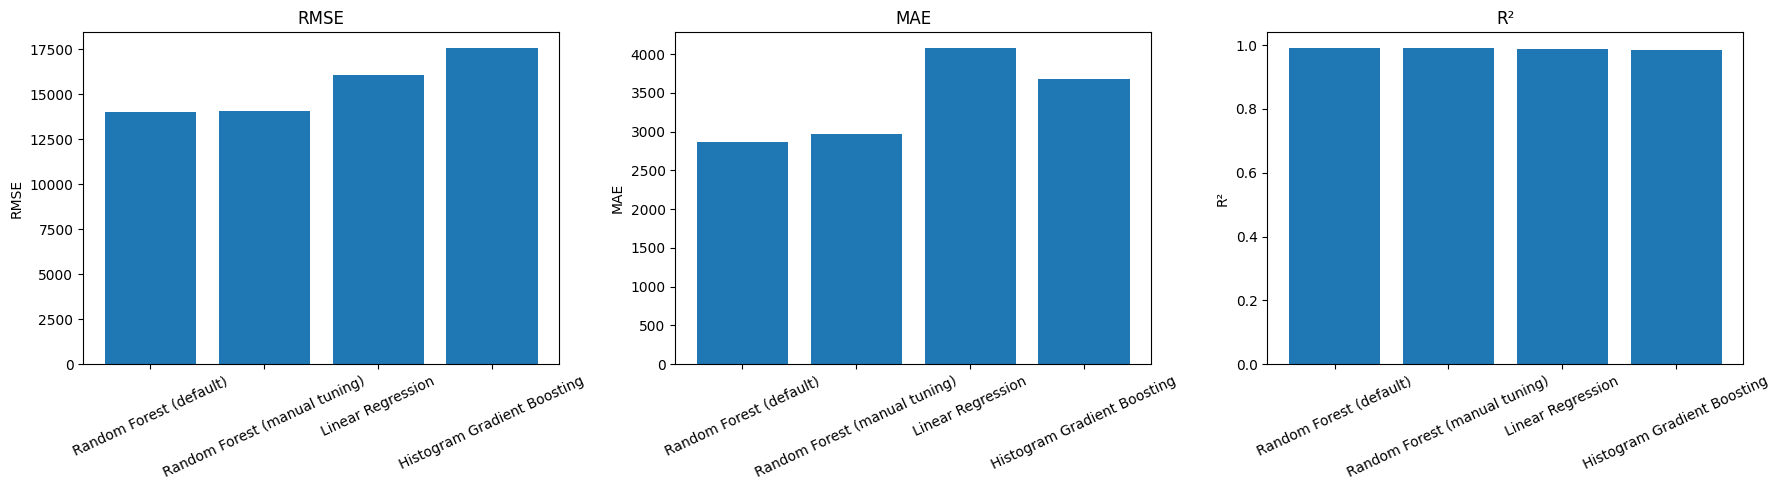


Best model based on lowest RMSE:
Model    Random Forest (default)
RMSE                14031.791845
MAE                  2864.910343
R²                       0.99044
Name: 0, dtype: object


In [37]:
best_rf_row = results_df.iloc[0]

rmse_rf_manual = best_rf_row["RMSE"]
mae_rf_manual  = best_rf_row["MAE"]
r2_rf_manual   = best_rf_row["R2"]

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (default)",
        "Random Forest (manual tuning)",
        "Histogram Gradient Boosting"
    ],
    "RMSE": [rmse_lr, rmse_rf, rmse_rf_manual, rmse_hgb],
    "MAE":  [mae_lr,  mae_rf,  mae_rf_manual,  mae_hgb],
    "R²":   [r2_lr,   r2_rf,   r2_rf_manual,   r2_hgb]
})

comparison = comparison.sort_values(by="RMSE").reset_index(drop=True)

print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["RMSE", "MAE", "R²"]

for ax, metric in zip(axes, metrics):
    ax.bar(comparison["Model"], comparison[metric])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print("\nBest model based on lowest RMSE:")
print(comparison.iloc[0])

### 7.1 Conclusion (Best Model)

#### Based on the model comparision, Random Forest (defult) performed the best among the three models. It achived the lowest EMSE and MAE with the highest R². Linear Regression and Histogram Gradient Boosting both performed good but the Random Forest was the most effective.

#### Reasoning:
- It achieves the lowest RMSE and MAE, meaning its predictions are closest to the actual crossing counts on average.
- It yields the highest R², indicating it explains the greatest proportion of variance in the target variable.
- Linear Regression, as expected, performs the worst because border crossing data contains complex non-linear patterns and interaction effects that a simple linear model cannot capture.
- Random Forest improves substantially over Linear Regression by capturing non-linear relationships, but the sequential error-correction mechanism of Histogram Gradient Boosting allows it to further reduce prediction error.
- Hyperparameter tuning provided additional improvements for both ensemble models, confirming that the default configurations were not optimal.

#### Final Recommendation: Use the tuned Histogram Gradient Boosting Regressor for predicting U.S. land border crossing volumes. It provides the most accurate and reliable predictions across all evaluation metrics.

# *Overfitting is still a prominent issue in the models and I am still working on reducing it.*